#  Fashion MNIST Classification

A complete implementation of the classification workflow from Chapter 3 of *Hands-On Machine Learning* by Aurélien Géron.

Models Evaluated:
- SGD Classifier
- Random Forest
- K-Nearest Neighbors
- One-vs-Rest SVC

Metrics:
- Precision
- Recall
- F1 Score
- ROC AUC
- Confusion Matrix
- Error Analysis

#  Dataset Preparation

The Fashion MNIST dataset consists of 28×28 grayscale clothing images belonging to 10 categories.

The objective is to classify each image into its corresponding clothing category.

In [2]:
import pandas as pd
train_df = pd.read_csv("/kaggle/input/datasets/organizations/zalando-research/fashionmnist/fashion-mnist_test.csv")
test_df = pd.read_csv("/kaggle/input/datasets/organizations/zalando-research/fashionmnist/fashion-mnist_train.csv")

In [3]:
train_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
test_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
X_train = train_df.drop("label",axis=1)
y_train = train_df["label"]

X_test = test_df.drop("label",axis=1)
y_test = test_df["label"]

In [6]:
X_train.shape

(10000, 784)

In [7]:
y_train.shape

(10000,)

#  Data Exploration

Before training any model, we visualize sample images and inspect the dataset structure.

This step helps verify data quality and build intuition about the classification task.

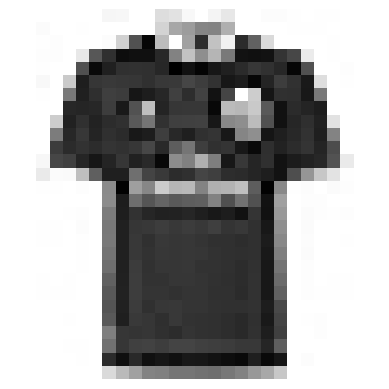

In [8]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
some_dress = X_train.iloc[0].to_numpy()
some_dress_image = some_dress.reshape(28,28)

plt.imshow(some_dress_image,cmap="binary")
plt.axis("off")
plt.show()

In [9]:
fashion_labels = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

print(
    "Label:",
    y_train.iloc[0],
    "-",
    fashion_labels[y_train.iloc[0]]
)
fashion_labels = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

print(
    "Label:",
    y_train.iloc[0],
    "-",
    fashion_labels[y_train.iloc[0]]
)

Label: 0 - T-shirt/top
Label: 0 - T-shirt/top


#  Binary Classification: Shirt vs Rest

Following Géron's workflow, the multiclass problem is temporarily converted into a binary task.

Target Class:
- Shirt (Class 6)

This allows us to study:
- Precision
- Recall
- F1 Score
- ROC Curves
- ROC AUC

In [10]:
y_train_shirt = (y_train == 6)
y_test_shirt = (y_test == 6)

#  SGD Classifier

The Stochastic Gradient Descent classifier serves as the baseline model.

Its primary advantage is computational efficiency while still providing competitive performance on large datasets.

In [11]:
from sklearn.linear_model import SGDClassifier
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train,y_train_shirt)

SGDClassifier(random_state=42)

In [12]:
some_item = X_test.iloc[0]

In [13]:
pred = sgd_clf.predict([some_item])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


In [14]:
print(pred)
print("Actual:", y_test_shirt.iloc[0])

[False]
Actual: False


In [15]:
from sklearn.model_selection import cross_val_predict
y_train_preds = cross_val_predict(
    sgd_clf,
    X_train,
    y_train_shirt,
    cv=3
)

In [16]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_train_shirt,y_train_preds)
print(cm)

[[8406  594]
 [ 454  546]]


#  Precision, Recall and F1 Score

Accuracy alone may be misleading for imbalanced classification problems.

Precision, Recall and F1 Score provide a more complete picture of model performance.

In [17]:
from sklearn.metrics import f1_score,precision_score,recall_score
print("Precision:",precision_score(y_train_shirt,y_train_preds))
print("Recall:",recall_score(y_train_shirt,y_train_preds))
print("F1 Score:",f1_score(y_train_shirt,y_train_preds))

Precision: 0.4789473684210526
Recall: 0.546
F1 Score: 0.5102803738317757


In [18]:
y_scores = cross_val_predict(
    sgd_clf,
    X_train,
    y_train_shirt,
    cv=3,
    method="decision_function"
)

In [19]:
from sklearn.metrics import precision_recall_curve

precisions,recalls,thresholds = precision_recall_curve(
    y_train_shirt,
    y_scores
)

#  ROC Curve and ROC AUC

ROC analysis evaluates the classifier across all possible decision thresholds.

A higher ROC AUC indicates stronger ranking ability and better separation between positive and negative classes.

In [20]:
from sklearn.metrics import roc_curve

fpr,tpr,thresholds = roc_curve(
    y_train_shirt,
    y_scores
)

In [21]:
from sklearn.metrics import roc_auc_score

roc_auc_score(
    y_train_shirt,
    y_scores
)

np.float64(0.8676796666666667)

#  Random Forest Classifier

Random Forest combines multiple decision trees to reduce variance and improve generalization.

This model is evaluated against SGD to compare ranking ability and classification performance.

In [22]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(
    random_state=42
)

y_probas_forest = cross_val_predict(
    forest_clf,
    X_train,
    y_train_shirt,
    cv=3,
    method="predict_proba"
)
y_scores_forest = y_probas_forest[:,1]

roc_auc_score(
    y_train_shirt,
    y_scores_forest
)

np.float64(0.9411893333333332)

In [23]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(
    y_train_shirt,
    y_scores_forest
)

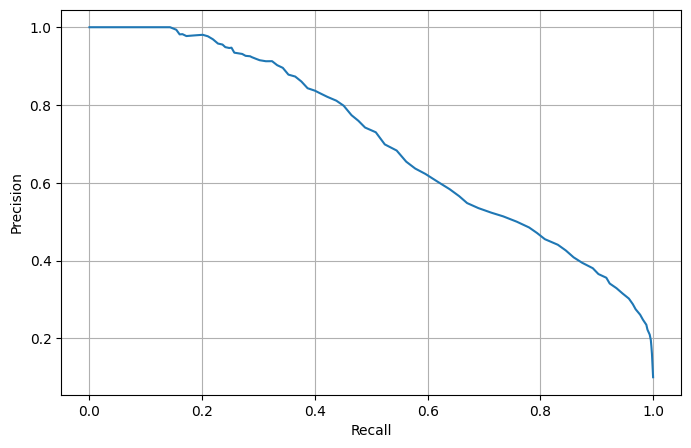

In [24]:
plt.figure(figsize=(8,5))
plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid()
plt.show()

In [25]:
idx = np.argmax(precisions >= 0.90)

print("Threshold:", thresholds[idx])
print("Precision:", precisions[idx])
print("Recall:", recalls[idx])

Threshold: 0.52
Precision: 0.9024390243902439
Recall: 0.333


In [26]:
from sklearn.ensemble import RandomForestClassifier
forest_clf = RandomForestClassifier()
forest_clf.fit(X_train,y_train)
y_pred = forest_clf.predict(X_test)

In [27]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8603

#  K-Nearest Neighbors

KNN classifies an image based on the labels of its nearest neighbors.

This algorithm is often surprisingly effective for image classification tasks.

In [28]:
from sklearn.neighbors import KNeighborsClassifier

knn_clf = KNeighborsClassifier()

knn_clf.fit(X_train,y_train)
y_preds = knn_clf.predict(X_test)

accuracy_score(y_test,y_preds)

0.8191666666666667

In [34]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype(np.float64))

Mean Accuracy: 0.8547005270413064


In [35]:
scr = cross_val_score(
    knn_clf,
    X_train_scaled,
    y_train,
    cv=3,
    scoring="accuracy"
)
print("Mean Accuracy:",scr.mean())

Mean Accuracy: 0.8192003363503716


In [37]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype(np.float64))
X_test_scaled = scaler.transform(X_test)
sco = cross_val_score(
    knn_clf,
    X_train_scaled,
    y_train,
    cv=3,
    scoring="accuracy"
)
print("Mean Accuracy:",sco.mean())

Mean Accuracy: 0.8547005270413064


#  Multiclass Classification

After exploring the binary task, we return to the full 10-class Fashion MNIST problem.

Multiple multiclass strategies are evaluated and compared.

In [38]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
ovr_clf = OneVsRestClassifier(SVC())
ovr_clf.fit(X_train,y_train)
pred = ovr_clf.predict(X_test)

In [39]:
accuracy_score(y_test,pred)

0.8615166666666667

In [41]:
from sklearn.neighbors import KNeighborsClassifier

knn_clf_3 = KNeighborsClassifier(n_neighbors=3,weights="distance")

knn_clf_3.fit(X_train_scaled, y_train)

y_pred = knn_clf_3.predict(X_test_scaled)

from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.8182666666666667

In [43]:
sc = cross_val_score(
    knn_clf_3,
    X_train_scaled,
    y_train,
    cv=3,
    scoring="accuracy"
)
print("Mean Accuracy:",sc.mean())

Mean Accuracy: 0.8171002763143741


In [46]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import SGDClassifier

ovr_clf_1 = OneVsRestClassifier(
    make_pipeline(
        StandardScaler(),
        SGDClassifier(random_state=42)
    )
)
ovr_clf_1.fit(X_train,y_train)

OneVsRestClassifier(estimator=Pipeline(steps=[('standardscaler',
                                               StandardScaler()),
                                              ('sgdclassifier',
                                               SGDClassifier(random_state=42))]))

In [47]:
predicts = ovr_clf_1.predict(X_test)
accuracy_score(y_test,predicts)

0.8195333333333333

In [49]:
ovr_svc = OneVsRestClassifier(SVC())
ovr_svc_scaled = OneVsRestClassifier(
    make_pipeline(
        StandardScaler(),
        SVC()
    )
)
ovr_svc_scaled.fit(X_train,y_train)
y_predict = ovr_svc_scaled.predict(X_test)
accuracy_score(y_test, y_predict)

0.8632666666666666

#  Hyperparameter Optimization

Grid Search is used to identify the best-performing Random Forest configuration through cross-validation.

This experiment investigates whether tuning can improve model performance.

In [50]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [20, None],
    "max_features": ["sqrt", "log2"]
}

rf_clf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    rf_clf,
    param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(grid_search.best_params_)
print(grid_search.best_score_)

{'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}
0.8576999271612825


#  Error Analysis

The confusion matrix reveals where the classifier struggles.

Rather than focusing only on accuracy, we examine which classes are most frequently confused and investigate the underlying reasons.

In [51]:
from sklearn.metrics import confusion_matrix
conf_mx = confusion_matrix(y_test,y_predict)
conf_mx

array([[5114,    7,   89,  280,   29,   11,  341,    2,  126,    1],
       [   7, 5794,   12,  146,   18,    0,    6,    0,   17,    0],
       [ 103,    2, 4801,   61,  664,    6,  286,    2,   75,    0],
       [ 159,   42,   74, 5315,  229,    1,  143,    0,   34,    3],
       [  10,    7,  495,  179, 4845,    4,  407,    0,   52,    1],
       [   2,    0,    0,    6,    0, 5573,    1,  267,   31,  120],
       [1001,   20,  725,  166,  576,    4, 3312,    1,  195,    0],
       [   0,    0,    0,    0,    0,  177,    0, 5615,   13,  195],
       [  15,    3,   22,   29,   23,   27,   36,   21, 5815,    9],
       [   1,    0,    0,    0,    0,   84,    0,  253,   50, 5612]])

#  Final Conclusions

Best Performing Model:
- Scaled OvR SVC

Best Accuracy:
- 86.33%

Key Findings:
- Accuracy alone is insufficient.
- ROC AUC provides deeper insight than F1 Score.
- Threshold tuning directly controls the precision-recall tradeoff.
- Fashion MNIST errors are largely semantically meaningful.
- Shirt, Pullover and Coat remain the most challenging classes.

This project successfully reproduces and extends the classification workflow from Chapter 3 of Géron's Hands-On Machine Learning.